PHASE 01: SETUP THE ENVIRONMENT



In [ ]:
# ============================================
# NLP CHATBOT DEVELOPMENT - Student Dropout Prediction
# IT24102236 - Piyarathne A.K.G.C.K
# ============================================

# Mount Google Drive and Install Libraries
from google.colab import drive
drive.mount('/content/drive')

!pip install nltk scikit-learn pandas numpy joblib transformers --quiet

import nltk
import pandas as pd
import numpy as np
import joblib
import json
import re
import random
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

print("Setup complete!")

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Setup complete!


In [ ]:
# Load feature importance to understand top risk factors
file_path = '/content/drive/MyDrive/Colab Notebooks/student_dropout_complete_data/feature_importance.csv'
feature_importance = pd.read_csv(file_path)
print("\n Top 10 Risk Factors:")
print(feature_importance.head(10))


 Top 10 Risk Factors:
                               feature  importance
0                           risk_score    0.082899
1                    success_rate_sem2    0.081920
2                    failure_rate_sem2    0.072157
3           academic_performance_score    0.070750
4  Curricular units 2nd sem (approved)    0.043276
5                    failure_rate_sem1    0.039772
6                    success_rate_sem1    0.038778
7  Curricular units 1st sem (approved)    0.038655
8     Curricular units 2nd sem (grade)    0.035611
9                       family_support    0.030492


PHASE 2: CREATE INTENT DATASET

In [ ]:
# Define Intent Categories Based on Risk Factors

intent_categories = {
    'academic_difficulty': [
        'struggling', 'hard', 'difficult', 'fail', 'grade', 'understand',
        'confused', 'homework', 'assignment', 'exam', 'test', 'course',
        'class', 'lecture', 'professor', 'teacher'
    ],
    'financial_concerns': [
        'money', 'tuition', 'fee', 'expensive', 'cost', 'scholarship',
        'financial', 'aid', 'loan', 'pay', 'afford', 'budget', 'bank'
    ],
    'time_management': [
        'time', 'busy', 'schedule', 'work', 'job', 'balance',
        'overwhelmed', 'deadline', 'procrastinate', 'late', 'tired'
    ],
    'motivation_issues': [
        'motivation', 'quit', 'dropout', 'give up', 'demotivated',
        'bored', 'interest', 'meaning', 'purpose', 'waste'
    ],
    'mental_health': [
        'stress', 'anxiety', 'depressed', 'mental', 'health',
        'overwhelmed', 'pressure', 'worry', 'scared', 'nervous'
    ],
    'family_support': [
        'family', 'parents', 'support', 'pressure', 'expectation',
        'home', 'house', 'children', 'child'
    ],
    'career_uncertainty': [
        'career', 'job', 'future', 'placement', 'industry',
        'company', 'salary', 'scope', 'opportunity'
    ],
    'health_issues': [
        'sick', 'illness', 'health', 'hospital', 'doctor',
        'medical', 'treatment', 'medicine'
    ],
    'technical_issues': [
        'computer', 'laptop', 'internet', 'wifi', 'software',
        'technical', 'system', 'error', 'bug'
    ],
    'advice_seeking': [
        'advice', 'suggest', 'recommend', 'help', 'guide',
        'what should', 'how to', 'tip', 'strategy'
    ],
    'risk_inquiry': [
        'risk', 'chance', 'probability', 'likely', 'predict',
        'dropout', 'graduate', 'success', 'forecast'
    ]
}

print("Defined", len(intent_categories), "intent categories")
for intent, keywords in intent_categories.items():
    print(f"   • {intent}: {len(keywords)} keywords")

Defined 11 intent categories
   • academic_difficulty: 16 keywords
   • financial_concerns: 13 keywords
   • time_management: 11 keywords
   • motivation_issues: 10 keywords
   • mental_health: 10 keywords
   • family_support: 9 keywords
   • career_uncertainty: 9 keywords
   • health_issues: 8 keywords
   • technical_issues: 9 keywords
   • advice_seeking: 9 keywords
   • risk_inquiry: 9 keywords


In [ ]:
# Create Training Dataset

# Base training phrases
training_phrases = [
    # ========== ACADEMIC DIFFICULTY (25 examples) ==========
    # Direct struggles
    ("I'm struggling with my math course", "academic_difficulty"),
    ("I'm having trouble with my classes", "academic_difficulty"),
    ("The coursework is too difficult", "academic_difficulty"),
    ("These classes are way too hard", "academic_difficulty"),
    ("I can't understand the lectures", "academic_difficulty"),

    # Grade related
    ("My grades are dropping", "academic_difficulty"),
    ("I failed my midterm exam", "academic_difficulty"),
    ("I got a bad grade on my assignment", "academic_difficulty"),
    ("My GPA is falling", "academic_difficulty"),
    ("I'm not doing well in any subject", "academic_difficulty"),

    # Specific subjects
    ("Calculus is impossible", "academic_difficulty"),
    ("I don't get this programming assignment", "academic_difficulty"),
    ("Physics equations are confusing", "academic_difficulty"),
    ("Can't understand the chemistry lab", "academic_difficulty"),
    ("Literature analysis is too complex", "academic_difficulty"),

    # General academic stress
    ("Falling behind in all classes", "academic_difficulty"),
    ("Can't keep up with the coursework", "academic_difficulty"),
    ("Too much homework to handle", "academic_difficulty"),
    ("Assignments are piling up", "academic_difficulty"),
    ("Studying isn't helping", "academic_difficulty"),

    # Professor/teaching related
    ("Professor goes too fast", "academic_difficulty"),
    ("Can't understand the teaching style", "academic_difficulty"),
    ("The TA isn't helpful", "academic_difficulty"),
    ("Need extra help with lectures", "academic_difficulty"),
    ("The material isn't explained well", "academic_difficulty"),

    # ========== FINANCIAL CONCERNS (25 examples) ==========
    # Tuition/fees
    ("Can't pay my tuition fees", "financial_concerns"),
    ("Tuition is due and I have no money", "financial_concerns"),
    ("I might get dropped for non-payment", "financial_concerns"),
    ("The fees are too expensive", "financial_concerns"),
    ("I can't afford this semester", "financial_concerns"),

    # Scholarships/financial aid
    ("Need scholarship information", "financial_concerns"),
    ("How do I apply for financial aid", "financial_concerns"),
    ("Lost my scholarship, what now", "financial_concerns"),
    ("Looking for emergency funding", "financial_concerns"),
    ("Financial aid office hours?", "financial_concerns"),

    # Basic needs
    ("Can't afford textbooks", "financial_concerns"),
    ("Struggling to buy course materials", "financial_concerns"),
    ("No money for food this week", "financial_concerns"),
    ("Can't pay for housing", "financial_concerns"),
    ("Need help with transportation costs", "financial_concerns"),

    # Family financial issues
    ("My parents lost their jobs", "financial_concerns"),
    ("Family can't support me anymore", "financial_concerns"),
    ("Financial emergency at home", "financial_concerns"),
    ("Family income dropped", "financial_concerns"),

    # Work/loans
    ("Need a part-time job urgently", "financial_concerns"),
    ("Student loan questions", "financial_concerns"),
    ("Can I get a payment plan", "financial_concerns"),
    ("Work-study options?", "financial_concerns"),
    ("Emergency loan availability", "financial_concerns"),
    ("Bank account issues", "financial_concerns"),

    # ========== TIME MANAGEMENT (20 examples) ==========
    ("No time to study", "time_management"),
    ("Too busy with work", "time_management"),
    ("Can't balance work and school", "time_management"),
    ("Always rushing deadlines", "time_management"),
    ("Procrastinating too much", "time_management"),
    ("Can't manage my schedule", "time_management"),
    ("Overwhelmed by workload", "time_management"),
    ("Falling behind on assignments", "time_management"),
    ("Never enough hours in the day", "time_management"),
    ("Need help organizing time", "time_management"),
    ("Work taking too much time", "time_management"),
    ("Family responsibilities piling up", "time_management"),
    ("Can't find study time", "time_management"),
    ("Always tired from juggling everything", "time_management"),
    ("Missing deadlines frequently", "time_management"),
    ("How to balance everything", "time_management"),
    ("Time management tips needed", "time_management"),
    ("Struggling with schedule", "time_management"),
    ("Can't prioritize tasks", "time_management"),
    ("Too many commitments", "time_management"),

    # ========== MOTIVATION ISSUES (20 examples) ==========
    ("I want to quit university", "motivation_issues"),
    ("Thinking of dropping out", "motivation_issues"),
    ("Lost all motivation", "motivation_issues"),
    ("Feel like giving up", "motivation_issues"),
    ("No interest in studies anymore", "motivation_issues"),
    ("What's the point of all this", "motivation_issues"),
    ("University feels meaningless", "motivation_issues"),
    ("Can't find motivation to attend class", "motivation_issues"),
    ("Burned out and exhausted", "motivation_issues"),
    ("Don't care about grades anymore", "motivation_issues"),
    ("Skipping classes due to lack of motivation", "motivation_issues"),
    ("No drive to study", "motivation_issues"),
    ("Feeling stuck and unmotivated", "motivation_issues"),
    ("Why am I even here", "motivation_issues"),
    ("Lost passion for learning", "motivation_issues"),
    ("Can't get myself to do anything", "motivation_issues"),
    ("Everything feels pointless", "motivation_issues"),
    ("Need motivation to continue", "motivation_issues"),
    ("Feeling hopeless about studies", "motivation_issues"),
    ("Should I take a break from school", "motivation_issues"),

    # ========== MENTAL HEALTH (20 examples) ==========
    ("Feeling very stressed", "mental_health"),
    ("Anxiety is overwhelming", "mental_health"),
    ("Feeling depressed", "mental_health"),
    ("Can't handle the pressure", "mental_health"),
    ("Need someone to talk to", "mental_health"),
    ("Mental health is suffering", "mental_health"),
    ("Having panic attacks", "mental_health"),
    ("Can't sleep from stress", "mental_health"),
    ("Overwhelmed by everything", "mental_health"),
    ("Need counseling services", "mental_health"),
    ("Feeling really down lately", "mental_health"),
    ("Stress affecting my studies", "mental_health"),
    ("Anxiety before every exam", "mental_health"),
    ("Feeling isolated and alone", "mental_health"),
    ("Can't focus due to stress", "mental_health"),
    ("Need mental health support", "mental_health"),
    ("Feeling burnt out", "mental_health"),
    ("Crying all the time", "mental_health"),
    ("Worried about everything", "mental_health"),
    ("Help with stress management", "mental_health"),

    # ========== FAMILY SUPPORT (15 examples) ==========
    ("Family doesn't support my education", "family_support"),
    ("Parents putting too much pressure", "family_support"),
    ("Family problems at home", "family_support"),
    ("No support system", "family_support"),
    ("Family wants me to work instead", "family_support"),
    ("Parents don't understand", "family_support"),
    ("Family crisis affecting studies", "family_support"),
    ("Need to take care of family", "family_support"),
    ("Home environment is stressful", "family_support"),
    ("Family expectations too high", "family_support"),
    ("Parents fighting at home", "family_support"),
    ("Family financial pressure", "family_support"),
    ("No quiet place to study at home", "family_support"),
    ("Family health issues", "family_support"),
    ("Need family counseling", "family_support"),

    # ========== CAREER UNCERTAINTY (15 examples) ==========
    ("Not sure about career path", "career_uncertainty"),
    ("Will I get a job after graduation", "career_uncertainty"),
    ("This degree might be useless", "career_uncertainty"),
    ("What are the job prospects", "career_uncertainty"),
    ("No clear career direction", "career_uncertainty"),
    ("Worried about future", "career_uncertainty"),
    ("Should I change my major", "career_uncertainty"),
    ("Career counseling needed", "career_uncertainty"),
    ("Industry doesn't interest me", "career_uncertainty"),
    ("Not sure what I want to do", "career_uncertainty"),
    ("Job market concerns", "career_uncertainty"),
    ("Internship opportunities", "career_uncertainty"),
    ("Career guidance needed", "career_uncertainty"),
    ("Placement worries", "career_uncertainty"),
    ("Salary expectations", "career_uncertainty"),

    # ========== HEALTH ISSUES (15 examples) ==========
    ("Been sick frequently", "health_issues"),
    ("Health affecting attendance", "health_issues"),
    ("Need medical leave", "health_issues"),
    ("Chronic illness issues", "health_issues"),
    ("Going to the hospital", "health_issues"),
    ("Doctor appointments during class", "health_issues"),
    ("Health deteriorating", "health_issues"),
    ("Can't concentrate due to health", "health_issues"),
    ("Need medical accommodation", "health_issues"),
    ("Recovering from surgery", "health_issues"),
    ("Medical condition flaring up", "health_issues"),
    ("Health insurance questions", "health_issues"),
    ("Doctor's notes for missed classes", "health_issues"),
    ("Health emergency", "health_issues"),
    ("Need health services on campus", "health_issues"),

    # ========== TECHNICAL ISSUES (15 examples) ==========
    ("Laptop not working", "technical_issues"),
    ("Internet connection problems", "technical_issues"),
    ("Can't access online resources", "technical_issues"),
    ("Software keeps crashing", "technical_issues"),
    ("LMS access issues", "technical_issues"),
    ("Computer too slow", "technical_issues"),
    ("Need technical support", "technical_issues"),
    ("Lost my data/files", "technical_issues"),
    ("Can't submit assignments online", "technical_issues"),
    ("Video lectures won't load", "technical_issues"),
    ("Login problems", "technical_issues"),
    ("Website not working", "technical_issues"),
    ("Email issues", "technical_issues"),
    ("Printer problems", "technical_issues"),
    ("Need loaner laptop", "technical_issues"),

    # ========== ADVICE SEEKING (15 examples) ==========
    ("What should I do to improve", "advice_seeking"),
    ("Can you give me some advice", "advice_seeking"),
    ("How can I do better", "advice_seeking"),
    ("Suggest some study tips", "advice_seeking"),
    ("What strategies work best", "advice_seeking"),
    ("Help me figure this out", "advice_seeking"),
    ("Need some guidance", "advice_seeking"),
    ("What would you recommend", "advice_seeking"),
    ("Tell me what to do", "advice_seeking"),
    ("Need academic advice", "advice_seeking"),
    ("How to improve my grades", "advice_seeking"),
    ("Best way to study", "advice_seeking"),
    ("Tips for success", "advice_seeking"),
    ("What resources are available", "advice_seeking"),
    ("How to handle this situation", "advice_seeking"),

    # ========== RISK INQUIRY (15 examples) ==========
    ("What is my dropout risk", "risk_inquiry"),
    ("Am I at risk of failing", "risk_inquiry"),
    ("Will I graduate on time", "risk_inquiry"),
    ("Predict my chances", "risk_inquiry"),
    ("How likely am I to drop out", "risk_inquiry"),
    ("Tell me my risk level", "risk_inquiry"),
    ("Am I in danger of failing", "risk_inquiry"),
    ("What's my probability of success", "risk_inquiry"),
    ("Risk assessment for me", "risk_inquiry"),
    ("Can you predict my outcome", "risk_inquiry"),
    ("Am I on track to graduate", "risk_inquiry"),
    ("Dropout probability", "risk_inquiry"),
    ("Success prediction", "risk_inquiry"),
    ("Academic standing check", "risk_inquiry"),
    ("Risk evaluation needed", "risk_inquiry"),

    # ========== GENERAL/GREETINGS (10 examples) ==========
    ("Hello", "greeting"),
    ("Hi there", "greeting"),
    ("Hey", "greeting"),
    ("Good morning", "greeting"),
    ("Good afternoon", "greeting"),
    ("Thanks", "gratitude"),
    ("Thank you", "gratitude"),
    ("Appreciate the help", "gratitude"),
    ("Bye", "farewell"),
    ("Goodbye", "farewell")
]

# Convert to DataFrame
df_intents = pd.DataFrame(training_phrases, columns=['text', 'intent'])
print(f"\nCreated ENHANCED training dataset with {len(df_intents)} examples")
print(f"\nIntent distribution:")
print(df_intents['intent'].value_counts())

# Save raw training data
df_intents.to_csv('chatbot_training_data_enhanced.csv', index=False)
print("Saved: chatbot_training_data_enhanced.csv")


Created ENHANCED training dataset with 210 examples

Intent distribution:
intent
academic_difficulty    25
financial_concerns     25
time_management        20
motivation_issues      20
mental_health          20
family_support         15
career_uncertainty     15
health_issues          15
technical_issues       15
advice_seeking         15
risk_inquiry           15
greeting                5
gratitude               3
farewell                2
Name: count, dtype: int64
Saved: chatbot_training_data_enhanced.csv


PHASE 3: TEXT PREPROCESSING

In [ ]:
# Text Preprocessing Pipeline

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Initialize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Clean and preprocess text for NLP
    """
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens
              if token not in stop_words and len(token) > 2]

    return ' '.join(tokens)

# Test the function
test_phrases = [
    "I'm struggling with my math course!",
    "Can't pay tuition fees :(",
    "No time to study because of work",
    "I want to quit university"
]

print("Text Preprocessing Test:")
for phrase in test_phrases:
    processed = preprocess_text(phrase)
    print(f"   Original: {phrase}")
    print(f"   Processed: {processed}\n")

# Apply preprocessing to all texts
df_intents['processed_text'] = df_intents['text'].apply(preprocess_text)

print("\nPreprocessing complete!")
print(df_intents[['text', 'processed_text']].head(10))

Text Preprocessing Test:
   Original: I'm struggling with my math course!
   Processed: struggling math course

   Original: Can't pay tuition fees :(
   Processed: cant pay tuition fee

   Original: No time to study because of work
   Processed: time study work

   Original: I want to quit university
   Processed: want quit university


Preprocessing complete!
                                 text            processed_text
0  I'm struggling with my math course    struggling math course
1  I'm having trouble with my classes             trouble class
2     The coursework is too difficult      coursework difficult
3      These classes are way too hard            class way hard
4     I can't understand the lectures   cant understand lecture
5              My grades are dropping            grade dropping
6            I failed my midterm exam       failed midterm exam
7  I got a bad grade on my assignment  got bad grade assignment
8                   My GPA is falling               gpa fall

In [ ]:
# Data Augmentation

def augment_training_data(df, augment_factor=2):
    """
    Augment training data by creating variations of existing sentences

    Args:
        df: DataFrame with 'text' and 'intent' columns
        augment_factor: How many variations to create per sentence

    Returns:
        Augmented DataFrame
    """
    augmented_texts = []
    augmented_intents = []

    # Synonym dictionary for common words
    synonyms = {
        'struggling': ['having trouble', 'having difficulty', 'finding it hard'],
        'hard': ['difficult', 'tough', 'challenging'],
        'help': ['assistance', 'support', 'aid'],
        'money': ['funds', 'finances', 'cash'],
        'study': ['learn', 'review', 'prepare'],
        'time': ['hours', 'schedule', 'availability'],
        'stress': ['pressure', 'anxiety', 'worry'],
        'quit': ['drop out', 'leave', 'withdraw'],
        'improve': ['get better', 'do better', 'enhance'],
        'risk': ['chance', 'probability', 'likelihood']
    }

    for idx, row in df.iterrows():
        text = row['text']
        intent = row['intent']

        # Original
        augmented_texts.append(text)
        augmented_intents.append(intent)

        # Create variations
        words = text.split()

        # Variation 1: Add "I think" or "I feel" prefix
        prefixes = ["I think ", "I feel like ", "I believe "]
        augmented_texts.append(random.choice(prefixes) + text)
        augmented_intents.append(intent)

        # Variation 2: Replace words with synonyms
        new_text = text
        for word, syn_list in synonyms.items():
            if word in text:
                new_text = text.replace(word, random.choice(syn_list))
        if new_text != text:
            augmented_texts.append(new_text)
            augmented_intents.append(intent)

        # Variation 3: Change word order (simple version)
        if len(words) > 3:
            shuffled = words.copy()
            random.shuffle(shuffled)
            augmented_texts.append(' '.join(shuffled))
            augmented_intents.append(intent)

    # Create new DataFrame
    df_augmented = pd.DataFrame({
        'text': augmented_texts,
        'intent': augmented_intents
    })

    # Remove duplicates
    df_augmented = df_augmented.drop_duplicates(subset=['text'])

    print(f"Data augmentation complete!")
    print(f"   Original samples: {len(df)}")
    print(f"   Augmented samples: {len(df_augmented)}")

    return df_augmented

# Apply augmentation
df_intents_augmented = augment_training_data(df_intents)

# Apply preprocessing to augmented data
df_intents_augmented['processed_text'] = df_intents_augmented['text'].apply(preprocess_text)

print("\nAugmented dataset distribution:")
print(df_intents_augmented['intent'].value_counts())

# Save augmented data
df_intents_augmented.to_csv('chatbot_training_data_augmented.csv', index=False)
print("Saved: chatbot_training_data_augmented.csv")

Data augmentation complete!
   Original samples: 210
   Augmented samples: 582

Augmented dataset distribution:
intent
academic_difficulty    77
financial_concerns     73
motivation_issues      58
time_management        57
mental_health          57
advice_seeking         46
risk_inquiry           44
family_support         42
career_uncertainty     38
health_issues          36
technical_issues       33
greeting               10
gratitude               7
farewell                4
Name: count, dtype: int64
Saved: chatbot_training_data_augmented.csv


PHASE 4: TRAIN INTENT CLASSIFIER

In [ ]:
# Training Intent Classifier Models with Multiple Models and Cross-validation

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import numpy as np

# Use augmented data if available, otherwise use original
try:
    X = df_intents_augmented['processed_text']
    y = df_intents_augmented['intent']
    print("Using AUGMENTED dataset")
except:
    X = df_intents['processed_text']
    y = df_intents['intent']
    print("Using original dataset")

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# ============================================
# Model 1: TF-IDF + Logistic Regression (with Grid Search)
# ============================================
print("\n" + "="*60)
print("Training Model 1: TF-IDF + Logistic Regression (Optimized)")
print("="*60)

# Parameter grid
param_grid_lr = {
    'tfidf__max_features': [500, 1000, 1500],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0],
    'clf__solver': ['liblinear', 'lbfgs']
}

pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Grid search
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best CV accuracy: {grid_lr.best_score_:.4f}")

# Test set evaluation
y_pred_lr = grid_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Test accuracy: {accuracy_lr:.4f}")

# ============================================
# Model 2: TF-IDF + Random Forest
# ============================================
print("\n" + "="*60)
print("Training Model 2: TF-IDF + Random Forest")
print("="*60)

pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Test accuracy: {accuracy_rf:.4f}")

# ============================================
# Model 3: TF-IDF + SVM (with class weights)
# ============================================
print("\n" + "="*60)
print("Training Model 3: TF-IDF + SVM (Weighted)")
print("="*60)

pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('clf', SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42))
])

pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Test accuracy: {accuracy_svm:.4f}")

# ============================================
# Model 4: Ensemble (Voting Classifier)
# ============================================
print("\n" + "="*60)
print("Training Model 4: Ensemble Classifier")
print("="*60)

from sklearn.ensemble import VotingClassifier

# Create individual pipelines for voting
pipeline1 = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

pipeline2 = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline3 = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('clf', SVC(kernel='linear', probability=True, random_state=42))
])

# Voting classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lr', pipeline1),
        ('rf', pipeline2),
        ('svm', pipeline3)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Test accuracy: {accuracy_voting:.4f}")

# ============================================
# Cross-validation comparison
# ============================================
print("\n" + "="*60)
print("CROSS-VALIDATION COMPARISON")
print("="*60)

models = {
    'Logistic Regression (Optimized)': grid_lr.best_estimator_,
    'Random Forest': pipeline_rf,
    'SVM': pipeline_svm,
    'Ensemble': voting_clf
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std()
    }
    print(f"\n{name}:")
    print(f"   CV Accuracy: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# ============================================
# Choose best model
# ============================================
print("\n" + "="*60)
print("SELECTING BEST MODEL")
print("="*60)

# Compare test accuracies
test_accuracies = {
    'Logistic Regression (Optimized)': accuracy_lr,
    'Random Forest': accuracy_rf,
    'SVM': accuracy_svm,
    'Ensemble': accuracy_voting
}

best_model_name = max(test_accuracies, key=test_accuracies.get)
best_model = models[best_model_name]
best_accuracy = test_accuracies[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

Using AUGMENTED dataset
Training set: 465 samples
Test set: 117 samples

Training Model 1: TF-IDF + Logistic Regression (Optimized)
Best parameters: {'clf__C': 10.0, 'clf__solver': 'lbfgs', 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}
Best CV accuracy: 0.9247
Test accuracy: 0.9915

Training Model 2: TF-IDF + Random Forest
Test accuracy: 0.9316

Training Model 3: TF-IDF + SVM (Weighted)
Test accuracy: 0.9658

Training Model 4: Ensemble Classifier
Test accuracy: 0.9658

CROSS-VALIDATION COMPARISON

Logistic Regression (Optimized):
   CV Accuracy: 0.6631 (+/- 0.1890)

Random Forest:
   CV Accuracy: 0.4675 (+/- 0.1001)

SVM:
   CV Accuracy: 0.6408 (+/- 0.1570)

Ensemble:
   CV Accuracy: 0.5808 (+/- 0.1583)

SELECTING BEST MODEL

Best Model: Logistic Regression (Optimized)
Test Accuracy: 0.9915

Detailed Classification Report:
                     precision    recall  f1-score   support

academic_difficulty       1.00      1.00      1.00        16
     advice_seeking       0.90

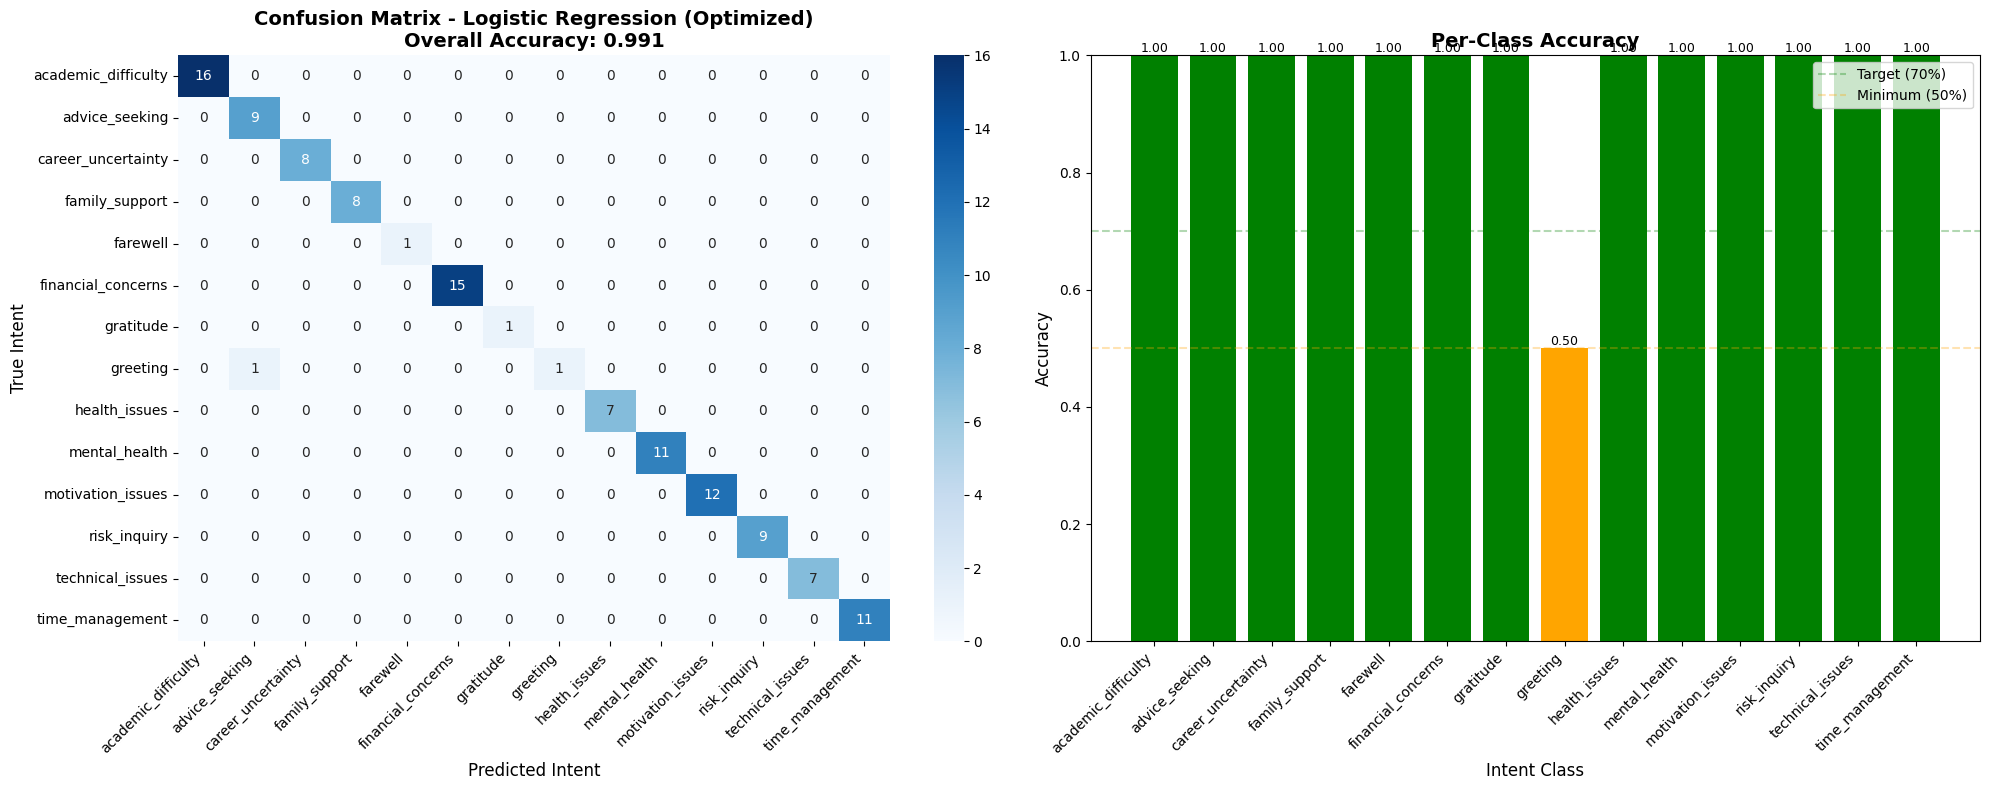

Saved: intent_confusion_matrix_enhanced.png

DETAILED CLASSIFICATION METRICS

Per-Class Metrics:
                     precision  recall  f1-score  support
academic_difficulty      1.000   1.000     1.000   16.000
advice_seeking           0.900   1.000     0.947    9.000
career_uncertainty       1.000   1.000     1.000    8.000
family_support           1.000   1.000     1.000    8.000
farewell                 1.000   1.000     1.000    1.000
financial_concerns       1.000   1.000     1.000   15.000
gratitude                1.000   1.000     1.000    1.000
greeting                 1.000   0.500     0.667    2.000
health_issues            1.000   1.000     1.000    7.000
mental_health            1.000   1.000     1.000   11.000
motivation_issues        1.000   1.000     1.000   12.000
risk_inquiry             1.000   1.000     1.000    9.000
technical_issues         1.000   1.000     1.000    7.000
time_management          1.000   1.000     1.000   11.000
accuracy                 0.991   

In [ ]:
# Confusion Matrix with Multiple Metrics

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Get predictions from best model
y_pred_best = best_model.predict(X_test)

# Get prediction probabilities if available
try:
    y_proba = best_model.predict_proba(X_test)
    confidence_scores = np.max(y_proba, axis=1)
    avg_confidence = np.mean(confidence_scores)
except:
    avg_confidence = None

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
intent_labels = best_model.classes_

# Calculate per-class accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Create figure with subplots
fig = plt.figure(figsize=(20, 8))

# ========== PLOT 1: Main Confusion Matrix ==========
ax1 = plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=intent_labels,
            yticklabels=intent_labels, ax=ax1)
ax1.set_title(f'Confusion Matrix - {best_model_name}\nOverall Accuracy: {accuracy_score(y_test, y_pred_best):.3f}',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Intent', fontsize=12)
ax1.set_ylabel('True Intent', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=10)

# ========== PLOT 2: Per-Class Accuracy Bar Chart ==========
ax2 = plt.subplot(1, 2, 2)

# Create color map based on accuracy
colors = ['red' if x < 0.3 else 'orange' if x < 0.6 else 'green' for x in class_accuracy]

bars = ax2.bar(range(len(intent_labels)), class_accuracy, color=colors)
ax2.set_xticks(range(len(intent_labels)))
ax2.set_xticklabels(intent_labels, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xlabel('Intent Class', fontsize=12)
ax2.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1])

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, class_accuracy)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.2f}', ha='center', va='bottom', fontsize=9)

# Add threshold lines
ax2.axhline(y=0.7, color='green', linestyle='--', alpha=0.3, label='Target (70%)')
ax2.axhline(y=0.5, color='orange', linestyle='--', alpha=0.3, label='Minimum (50%)')
ax2.legend()

plt.tight_layout()
plt.savefig('intent_confusion_matrix_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: intent_confusion_matrix_enhanced.png")

# ========== Detailed Metrics Table ==========
print("\n" + "="*60)
print("DETAILED CLASSIFICATION METRICS")
print("="*60)

# Calculate metrics per class
report_dict = classification_report(y_test, y_pred_best, output_dict=True)

# Create DataFrame for better display
metrics_df = pd.DataFrame(report_dict).T
metrics_df = metrics_df.round(3)

# Display metrics
print("\nPer-Class Metrics:")
print(metrics_df)

# Identify problem classes
print("\nClasses with low performance (< 0.5 accuracy):")
low_perf_classes = [intent_labels[i] for i, acc in enumerate(class_accuracy) if acc < 0.5]
if low_perf_classes:
    for cls in low_perf_classes:
        print(f"   • {cls}: {class_accuracy[list(intent_labels).index(cls)]:.3f}")
else:
    print("   ✓ All classes performing well!")

# ========== Sample Misclassifications Analysis ==========
print("\n" + "="*60)
print("MISCLASSIFICATION ANALYSIS")
print("="*60)

# Find indices where prediction is wrong
misclassified_idx = np.where(y_test != y_pred_best)[0]

if len(misclassified_idx) > 0:
    # Show first 5 misclassifications
    print("\nSample Misclassifications (first 5):")
    for i, idx in enumerate(misclassified_idx[:5]):
        true = y_test.iloc[idx]
        pred = y_pred_best[idx]
        text = X_test.iloc[idx]
        print(f"\n{i+1}. True: {true:<20} | Pred: {pred:<20}")
        print(f"   Text: \"{text[:50]}...\"")

    # Common confusion pairs
    print("\nCommon Confusion Patterns:")
    confusion_pairs = {}
    for true, pred in zip(y_test, y_pred_best):
        if true != pred:
            pair = f"{true} → {pred}"
            confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

    # Sort by frequency
    sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
    for pair, count in sorted_pairs[:5]:
        print(f"   • {pair}: {count} times")
else:
    print("✓ No misclassifications found!")

# ========== Confidence Analysis ==========
if avg_confidence:
    print("\n" + "="*60)
    print("CONFIDENCE ANALYSIS")
    print("="*60)
    print(f"\nAverage confidence score: {avg_confidence:.3f}")

    # Confidence distribution
    correct_pred = y_test == y_pred_best
    if avg_confidence:
        correct_confidence = confidence_scores[correct_pred].mean() if any(correct_pred) else 0
        incorrect_confidence = confidence_scores[~correct_pred].mean() if any(~correct_pred) else 0

        print(f"Average confidence (correct predictions): {correct_confidence:.3f}")
        print(f"Average confidence (incorrect predictions): {incorrect_confidence:.3f}")

# ========== Recommendations ==========
print("\n" + "="*60)
print("RECOMMENDATIONS FOR IMPROVEMENT")
print("="*60)

# Identify specific issues
if any(class_accuracy < 0.5):
    print("\nImmediate improvements needed for:")
    for cls in low_perf_classes:
        print(f"   • {cls}")
        print(f"     - Add more training examples for '{cls}'")
        print(f"     - Review keyword patterns for '{cls}'")
        print(f"     - Check for confusion with similar intents")

if len(misclassified_idx) > len(y_test) * 0.3:  # More than 30% misclassified
    print("\n Overall model needs improvement:")
    print("   • Increase training data size")
    print("   • Try different feature extraction methods")
    print("   • Consider using word embeddings")

print("\nAnalysis complete!")

PHASE 5: CREATE RESPONSE TEMPLATES

In [ ]:
# Create Response Templates Based on Risk Level

# Load top risk factors from feature importance
top_risk_factors = feature_importance.head(10)['feature'].tolist()
print(f" Top Risk Factors: {top_risk_factors}")

# Create response templates for each intent and risk level
responses = {
    "academic_difficulty": {
        "LOW": {
            "text": "Your academic risk is low! Here are some study tips based on successful students:",
            "tips": [
                "Form study groups with classmates",
                "Use the university's tutoring center",
                "Review material within 24 hours of lectures",
                "Create a consistent study schedule",
                "Use active recall techniques"
            ],
            "resources": [
                "Academic Success Center - Room 203",
                "Peer Tutoring Program - sign up online",
                "Study Skills Workshop - every Tuesday"
            ]
        },
        "MEDIUM": {
            "text": "You're showing some academic concerns. We recommend:",
            "tips": [
                "Meet with your academic advisor this week",
                "Consider reducing your course load next semester",
                "Use professor's office hours regularly",
                "Join a study group for difficult subjects"
            ],
            "resources": [
                "Academic Advising - Book appointment online",
                "Supplemental Instruction sessions",
                "Time management workshop - Thursday 2pm"
            ]
        },
        "HIGH": {
            "text": " URGENT: Your academic performance needs immediate attention.",
            "tips": [
                "Schedule mandatory meeting with academic advisor TODAY",
                "Review your study strategies immediately",
                "Consider academic probation support program",
                "Attend all office hours this week"
            ],
            "resources": [
                "Academic Alert System - you've been flagged",
                "Dean's Office - emergency appointment available",
                "Student Success Team - will contact you within 24h"
            ]
        }
    },

    "financial_concerns": {
        "LOW": {
            "text": "Your financial situation looks stable, but planning ahead helps:",
            "tips": [
                "Apply for scholarships for next semester",
                "Create a student budget",
                "Look into on-campus job opportunities",
                "Check if you qualify for work-study"
            ],
            "resources": [
                "Financial Aid Office - open Mon-Fri 9-5",
                "Scholarship database: scholarships.university.edu",
                "Student Employment Office - Room 105"
            ]
        },
        "MEDIUM": {
            "text": "You may be eligible for additional financial support:",
            "tips": [
                "Complete the FAFSA/financial aid application immediately",
                "Visit Financial Aid Office this week",
                "Apply for emergency grants",
                "Discuss payment plans with Bursar's Office"
            ],
            "resources": [
                "Financial Aid Emergency Fund - apply online",
                "Bursar's Office - payment plan options",
                "Student Emergency Assistance Program"
            ]
        },
        "HIGH": {
            "text": " URGENT FINANCIAL CONCERN: You need immediate assistance.",
            "tips": [
                "GO TO FINANCIAL AID OFFICE TODAY",
                "Apply for emergency financial aid immediately",
                "Speak with Dean of Students about options",
                "Don't miss tuition deadline - seek help NOW"
            ],
            "resources": [
                "Emergency Financial Aid - walk-ins accepted",
                "Dean of Students - emergency contact",
                "Student Crisis Fund - application available"
            ]
        }
    },

    "time_management": {
        "LOW": {
            "text": "Your time management is good! Here's how to maintain it:",
            "tips": [
                "Use a planner or digital calendar",
                "Block out study time for each subject",
                "Take regular breaks (Pomodoro technique)",
                "Review your schedule weekly"
            ],
            "resources": [
                "Time Management Workshop - online module",
                "Planner templates available at Student Success",
                "Productivity apps: recommended list"
            ]
        },
        "MEDIUM": {
            "text": "Time management could be improved. Try these strategies:",
            "tips": [
                "Create a fixed daily study schedule",
                "Reduce non-essential commitments",
                "Use the 2:1 ratio (2 hours study : 1 hour work)",
                "Set specific goals for each study session"
            ],
            "resources": [
                "Time Management Counseling - book appointment",
                "Weekly planning template - download",
                "Student Success Workshop - Thursday"
            ]
        },
        "HIGH": {
            "text": " Your time management is critically impacting your studies.",
            "tips": [
                "MEET WITH ACADEMIC ADVISOR IMMEDIATELY",
                "Consider reducing work hours or course load",
                "Create emergency study plan for this week",
                "Use university's time management coach"
            ],
            "resources": [
                "Academic Advising - emergency appointment",
                "Student Success Coordinator - assigned to you",
                "Time Management Intensive Program"
            ]
        }
    },

    "motivation_issues": {
        "LOW": {
            "text": "Staying motivated is key! Here are some ideas:",
            "tips": [
                "Connect with student clubs and organizations",
                "Set small, achievable weekly goals",
                "Find a study buddy or accountability partner",
                "Remember your long-term career goals"
            ],
            "resources": [
                "Student Life - club listings",
                "Motivation Workshop - online",
                "Peer Mentoring Program"
            ]
        },
        "MEDIUM": {
            "text": "Loss of motivation is common but manageable:",
            "tips": [
                "Speak with a counselor about motivation",
                "Take a career assessment test",
                "Talk to professors in your major",
                "Join a support group for students"
            ],
            "resources": [
                "Counseling Center - appointment available",
                "Career Services - explore options",
                "Student Support Group - meets Fridays"
            ]
        },
        "HIGH": {
            "text": " Your motivation concerns need immediate attention:",
            "tips": [
                "SCHEDULE COUNSELING APPOINTMENT TODAY",
                "Talk to someone you trust immediately",
                "Don't make any decisions alone",
                "Take a mental health day if needed"
            ],
            "resources": [
                "Counseling Center - crisis line: 555-0123",
                "24/7 Student Support Hotline",
                "Dean of Students - immediate assistance"
            ]
        }
    },

    "risk_inquiry": {
        "text": "Based on your profile, your dropout risk level is {risk_level}. The main factors affecting this are: {factors}",
        "LOW": "You're on track! Key strengths: {factors}",
        "MEDIUM": "You have some risk factors to address: {factors}",
        "HIGH": " You have multiple high-risk factors: {factors}"
    },

    "advice_seeking": {
        "text": "Based on your {risk_level} risk profile, here's personalized advice:",
        "LOW": "Focus on maintaining your good habits. Key areas: {factors}",
        "MEDIUM": "Priority areas for improvement: {factors}",
        "HIGH": "URGENT: Address these factors immediately: {factors}"
    },

    "default": {
        "text": "I understand you're reaching out for help. A student success counselor will contact you within 24 hours.",
        "resources": ["Student Success Center", "Counseling Services", "Academic Advising"]
    }
}

# Save response templates
with open('response_templates.json', 'w') as f:
    json.dump(responses, f, indent=2)

print(" Saved: response_templates.json")
print("\n Response templates created for:")
for intent in responses.keys():
    if intent != 'default':
        print(f"   • {intent}")

 Top Risk Factors: ['risk_score', 'success_rate_sem2', 'failure_rate_sem2', 'academic_performance_score', 'Curricular units 2nd sem (approved)', 'failure_rate_sem1', 'success_rate_sem1', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (grade)', 'family_support']
 Saved: response_templates.json

 Response templates created for:
   • academic_difficulty
   • financial_concerns
   • time_management
   • motivation_issues
   • risk_inquiry
   • advice_seeking


PHASE 6: CREATE CHATBOT BACKEND API

In [ ]:
# Chatbot Class with Improved Intent Detection

import json
import re
import random
from typing import Dict, List, Tuple, Optional
from datetime import datetime
import numpy as np
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

class StudentDropoutChatbot:
    """
    Enhanced chatbot for student dropout prediction with improved intent detection
    """

    def __init__(self, intent_model, responses, risk_factors, vectorizer=None):
        """
        Initialize chatbot with improved intent detection

        Args:
            intent_model: Trained intent classification model
            responses: Response templates dictionary
            risk_factors: List of top risk factors
            vectorizer: Optional vectorizer (if not included in pipeline)
        """
        self.model = intent_model
        self.responses = responses
        self.risk_factors = risk_factors
        self.vectorizer = vectorizer
        self.conversation_history = []
        self.user_sessions = {}

        # Initialize NLP tools
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

        # Intent keywords with weights
        self.intent_keywords = {
            'academic_difficulty': {
                'primary': ['struggling', 'difficult', 'hard', 'fail', 'failing', 'failed', 'trouble'],
                'secondary': ['grade', 'grades', 'exam', 'test', 'course', 'class', 'homework',
                             'assignment', 'understand', 'confused', 'behind', 'dropping'],
                'context': ['math', 'science', 'subject', 'semester', 'professor', 'teacher', 'lecture']
            },
            'financial_concerns': {
                'primary': ['money', 'tuition', 'fees', 'expensive', 'cost', 'pay', 'afford'],
                'secondary': ['financial', 'aid', 'scholarship', 'loan', 'budget', 'fund', 'emergency'],
                'context': ['bank', 'debt', 'support', 'assistance', 'help', 'work', 'job']
            },
            'time_management': {
                'primary': ['time', 'busy', 'schedule', 'deadline', 'overwhelmed', 'balance'],
                'secondary': ['work', 'job', 'procrastinate', 'late', 'tired', 'hours', 'manage'],
                'context': ['morning', 'night', 'week', 'month', 'plan', 'organization']
            },
            'motivation_issues': {
                'primary': ['quit', 'dropout', 'give up', 'motivation', 'demotivated', 'unmotivated'],
                'secondary': ['bored', 'interest', 'purpose', 'waste', 'meaning', 'point', 'care'],
                'context': ['career', 'future', 'why', 'continue', 'stop']
            },
            'mental_health': {
                'primary': ['stress', 'anxiety', 'depressed', 'depression', 'mental', 'panic'],
                'secondary': ['overwhelmed', 'pressure', 'worry', 'scared', 'nervous', 'sleep', 'crying'],
                'context': ['counseling', 'help', 'talk', 'support', 'crisis', 'therapy']
            },
            'family_support': {
                'primary': ['family', 'parents', 'home', 'house', 'mother', 'father'],
                'secondary': ['support', 'pressure', 'expectation', 'children', 'child', 'sibling'],
                'context': ['understanding', 'help', 'approval', 'crisis', 'problem']
            },
            'career_uncertainty': {
                'primary': ['career', 'job', 'future', 'placement', 'profession'],
                'secondary': ['industry', 'company', 'salary', 'scope', 'opportunity', 'prospect'],
                'context': ['confused', 'unsure', 'change', 'major', 'degree', 'worth']
            },
            'health_issues': {
                'primary': ['sick', 'illness', 'health', 'hospital', 'doctor', 'medical'],
                'secondary': ['treatment', 'medicine', 'appointment', 'condition', 'chronic'],
                'context': ['recovery', 'surgery', 'pain', 'emergency']
            },
            'technical_issues': {
                'primary': ['computer', 'laptop', 'internet', 'wifi', 'technical', 'technology'],
                'secondary': ['software', 'system', 'error', 'bug', 'crash', 'access'],
                'context': ['online', 'login', 'submit', 'website', 'platform']
            },
            'advice_seeking': {
                'primary': ['advice', 'suggest', 'recommend', 'help', 'guide', 'tip'],
                'secondary': ['what should', 'how to', 'strategy', 'improve', 'better', 'best'],
                'context': ['way', 'approach', 'method', 'resource']
            },
            'risk_inquiry': {
                'primary': ['risk', 'chance', 'probability', 'likely', 'predict', 'forecast'],
                'secondary': ['dropout', 'graduate', 'success', 'assessment', 'evaluation', 'standing'],
                'context': ['odds', 'possibility', 'future', 'outcome']
            },
            'greeting': {
                'primary': ['hello', 'hi', 'hey', 'greetings', 'good morning', 'good afternoon'],
                'secondary': ['start', 'begin', 'help', 'assistance'],
                'context': []
            },
            'gratitude': {
                'primary': ['thanks', 'thank you', 'appreciate', 'grateful'],
                'secondary': ['helpful', 'awesome', 'great'],
                'context': []
            },
            'farewell': {
                'primary': ['bye', 'goodbye', 'see you', 'talk later'],
                'secondary': ['exit', 'leave', 'end'],
                'context': []
            }
        }

        # Academic terms for context boosting
        self.academic_terms = {
            'subjects': ['math', 'mathematics', 'science', 'physics', 'chemistry', 'biology',
                        'calculus', 'algebra', 'statistics', 'programming', 'coding'],
            'assignments': ['homework', 'project', 'paper', 'essay', 'presentation', 'lab', 'report'],
            'exams': ['midterm', 'final', 'quiz', 'test', 'exam', 'assessment', 'evaluation'],
            'resources': ['library', 'tutor', 'tutoring', 'office hours', 'study group']
        }

        print(" Enhanced chatbot initialized with improved intent detection")
        print(f"   • {len(self.intent_keywords)} intent categories")
        print(f"   • Risk factors loaded: {len(self.risk_factors)}")

    def preprocess_input(self, text):
        """
        Clean and preprocess user input

        Args:
            text: Raw user input

        Returns:
            Preprocessed text
        """
        if not text or not isinstance(text, str):
            return ""

        # Convert to lowercase
        text = text.lower()

        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))

        # Remove numbers
        text = re.sub(r'\d+', '', text)

        # Remove extra spaces
        text = ' '.join(text.split())

        return text

    def detect_intent_rule_based(self, text):
        """
        Rule-based intent detection using keyword matching

        Args:
            text: Preprocessed user message

        Returns:
            Tuple of (intent, confidence_score)
        """
        words = text.split()
        text_lower = text.lower()

        # Score each intent
        scores = {}
        matched_keywords = {}

        for intent, keywords in self.intent_keywords.items():
            score = 0
            matched = []

            # Check primary keywords (highest weight - 3 points)
            for kw in keywords['primary']:
                if kw in text_lower:
                    score += 3
                    matched.append(kw)
                # Check exact word matches
                if any(kw == word for word in words):
                    score += 2

            # Check secondary keywords (medium weight - 2 points)
            for kw in keywords['secondary']:
                if kw in text_lower:
                    score += 2
                    matched.append(kw)
                if any(kw == word for word in words):
                    score += 1

            # Check context keywords (low weight - 1 point)
            for kw in keywords.get('context', []):
                if kw in text_lower:
                    score += 1

            scores[intent] = score
            if matched:
                matched_keywords[intent] = matched[:3]  # Store first 3 matches

        # Boost academic_difficulty score if academic terms are found
        for category, terms in self.academic_terms.items():
            for term in terms:
                if term in text_lower:
                    scores['academic_difficulty'] += 2
                    if 'academic_difficulty' not in matched_keywords:
                        matched_keywords['academic_difficulty'] = []
                    matched_keywords['academic_difficulty'].append(term)

        # Get highest scoring intent
        if any(scores.values()):
            best_intent = max(scores, key=scores.get)
            max_score = scores[best_intent]

            # Normalize confidence to 0-1 range
            # Max possible score depends on message length, but cap at 20
            confidence = min(max_score / 15, 1.0) if max_score > 0 else 0.1

            # Boost confidence if we have primary keyword matches
            if best_intent in matched_keywords:
                confidence = min(confidence + 0.2, 1.0)
        else:
            best_intent = 'general'
            confidence = 0.3
            matched_keywords = {}

        return best_intent, confidence, matched_keywords.get(best_intent, [])

    def detect_intent_ml(self, text):
        """
        ML-based intent detection using trained model

        Args:
            text: Preprocessed user message

        Returns:
            Tuple of (intent, confidence_score)
        """
        try:
            # Check if model has predict_proba
            if hasattr(self.model, 'predict_proba'):
                proba = self.model.predict_proba([text])[0]
                intent_idx = np.argmax(proba)
                intent = self.model.classes_[intent_idx]
                confidence = proba[intent_idx]
            else:
                # Fallback to predict
                intent = self.model.predict([text])[0]
                confidence = 0.7  # Default confidence
        except Exception as e:
            print(f"⚠️ ML detection error: {e}")
            intent = 'general'
            confidence = 0.3

        return intent, confidence

    def detect_intent(self, text, use_hybrid=True):
        """
        Hybrid intent detection combining rule-based and ML approaches

        Args:
            text: User message
            use_hybrid: If True, combine both methods

        Returns:
            Tuple of (intent, confidence_score, matched_keywords)
        """
        if not text:
            return 'general', 0.1, []

        # Preprocess
        processed = self.preprocess_input(text)

        # Rule-based detection
        rule_intent, rule_conf, keywords = self.detect_intent_rule_based(processed)

        if not use_hybrid:
            return rule_intent, rule_conf, keywords

        # ML-based detection
        ml_intent, ml_conf = self.detect_intent_ml(processed)

        # Combine results (weighted average)
        # Give more weight to rule-based if confidence is high
        if rule_conf > 0.7:
            # Rule-based is confident, trust it more
            final_intent = rule_intent
            final_conf = (rule_conf * 0.7 + ml_conf * 0.3)
        elif ml_conf > 0.7:
            # ML is confident, trust it more
            final_intent = ml_intent
            final_conf = (ml_conf * 0.7 + rule_conf * 0.3)
        else:
            # Both have low confidence, check if they agree
            if rule_intent == ml_intent:
                final_intent = rule_intent
                final_conf = (rule_conf + ml_conf) / 2
            else:
                # They disagree, use the higher confidence one
                if rule_conf >= ml_conf:
                    final_intent = rule_intent
                    final_conf = rule_conf
                else:
                    final_intent = ml_intent
                    final_conf = ml_conf

        return final_intent, final_conf, keywords

    def get_risk_factors_by_level(self, risk_level):
        """
        Get relevant risk factors based on risk level

        Args:
            risk_level: LOW, MEDIUM, or HIGH

        Returns:
            List of risk factors
        """
        if risk_level == 'HIGH':
            return self.risk_factors[:5] if len(self.risk_factors) >= 5 else self.risk_factors
        elif risk_level == 'MEDIUM':
            if len(self.risk_factors) > 7:
                return self.risk_factors[3:8]
            elif len(self.risk_factors) > 3:
                return self.risk_factors[3:]
            else:
                return self.risk_factors
        else:  # LOW
            if len(self.risk_factors) > 9:
                return self.risk_factors[5:10]
            elif len(self.risk_factors) > 5:
                return self.risk_factors[5:]
            else:
                return self.risk_factors[-3:] if self.risk_factors else []

    def format_response(self, response_text, tips=None, resources=None):
        """
        Format response with tips and resources

        Args:
            response_text: Main response text
            tips: List of tips
            resources: List of resources

        Returns:
            Formatted response string
        """
        formatted = response_text

        if tips and len(tips) > 0:
            formatted += "\n\n Tips:\n"
            for tip in tips[:3]:  # Limit to 3 tips
                formatted += f"• {tip}\n"

        if resources and len(resources) > 0:
            formatted += "\n\n Resources:\n"
            for resource in resources[:3]:  # Limit to 3 resources
                formatted += f"• {resource}\n"

        return formatted

    def generate_response(self, intent, risk_level, user_message, user_id=None):
        """
        Generate personalized response based on intent and risk level

        Args:
            intent: Detected intent
            risk_level: Risk level (LOW/MEDIUM/HIGH)
            user_message: Original user message
            user_id: Optional user identifier

        Returns:
            Response dictionary with message and metadata
        """
        # Store conversation
        conversation_entry = {
            'timestamp': datetime.now().isoformat(),
            'user_message': user_message,
            'intent': intent,
            'risk_level': risk_level
        }

        if user_id:
            if user_id not in self.user_sessions:
                self.user_sessions[user_id] = []
            self.user_sessions[user_id].append(conversation_entry)

        self.conversation_history.append(conversation_entry)

        # Get risk factors based on level
        factors = self.get_risk_factors_by_level(risk_level)
        factors_text = ', '.join(factors[:3]) if factors else "academic performance"

        # Initialize response components
        response_text = ""
        tips = []
        resources = []

        # Handle special intents
        if intent == 'greeting':
            response_text = "Hello! I'm your academic assistant. How can I help you today?"
            tips = ["Ask about your dropout risk", "Get study tips", "Find resources"]
            resources = ["Student Success Center", "Academic Advising"]

        elif intent == 'gratitude':
            response_text = "You're welcome! I'm here to help. Is there anything else you'd like to know?"

        elif intent == 'farewell':
            response_text = "Goodbye! Remember, I'm here whenever you need support. Take care!"

        elif intent == 'general':
            response_text = "I'm here to help with your academic success. You can ask me about:\n• Your dropout risk\n• Academic difficulties\n• Financial concerns\n• Time management\n• Motivation issues"
            tips = ["Try asking a specific question", "Select from the suggestions below"]
            resources = ["Student Support Services"]

        else:
            # Look up response in templates
            if intent in self.responses:
                intent_responses = self.responses[intent]

                if isinstance(intent_responses, dict):
                    # Check if risk level exists in responses
                    if risk_level in intent_responses:
                        response_data = intent_responses[risk_level]

                        if isinstance(response_data, dict):
                            response_text = response_data.get('text', '')
                            tips = response_data.get('tips', [])
                            resources = response_data.get('resources', [])
                        else:
                            response_text = str(response_data)
                    else:
                        # Try to get default text
                        response_text = intent_responses.get('text', str(intent_responses))
                        tips = intent_responses.get('tips', []) if isinstance(intent_responses, dict) else []
                        resources = intent_responses.get('resources', []) if isinstance(intent_responses, dict) else []
                else:
                    response_text = str(intent_responses)
            else:
                # Fallback response
                response_text = "I understand you're reaching out for help. A student success counselor will contact you within 24 hours."
                resources = ["Student Success Center", "Counseling Services", "Academic Advising"]

        # Replace placeholders
        response_text = response_text.replace('{factors}', factors_text)
        response_text = response_text.replace('{risk_level}', risk_level)

        # Format final response
        formatted_response = self.format_response(response_text, tips, resources)

        return {
            'response': formatted_response,
            'intent': intent,
            'risk_level': risk_level,
            'tips': tips[:3],
            'resources': resources[:3],
            'factors': factors[:3]
        }

    def chat(self, user_message, risk_level='MEDIUM', user_id=None):
        """
        Main chat function

        Args:
            user_message: User's message
            risk_level: Risk level (LOW/MEDIUM/HIGH)
            user_id: Optional user identifier

        Returns:
            Complete response dictionary
        """
        if not user_message or not user_message.strip():
            return {
                'response': "Please type a message. I'm here to help!",
                'intent': 'empty',
                'risk_level': risk_level,
                'tips': [],
                'resources': []
            }

        # Detect intent
        intent, confidence, keywords = self.detect_intent(user_message, use_hybrid=True)

        # Generate response
        response = self.generate_response(intent, risk_level, user_message, user_id)

        # Add metadata
        response['confidence'] = float(confidence)
        response['keywords_matched'] = keywords
        response['user_message'] = user_message

        return response

    def get_conversation_history(self, user_id=None):
        """
        Get conversation history

        Args:
            user_id: Optional user ID to get specific user's history

        Returns:
            List of conversation entries
        """
        if user_id:
            return self.user_sessions.get(user_id, [])
        return self.conversation_history

    def export_conversations(self, filepath='conversations.json'):
        """
        Export all conversations to JSON file

        Args:
            filepath: Path to save JSON file
        """
        data = {
            'conversations': self.conversation_history,
            'user_sessions': self.user_sessions
        }
        with open(filepath, 'w') as f:
            json.dump(data, f, indent=2)
        print(f" Conversations exported to {filepath}")

    def get_suggestions(self, intent=None):
        """
        Get message suggestions based on intent

        Args:
            intent: Optional intent to get specific suggestions

        Returns:
            List of suggestion strings
        """
        suggestions = {
            'academic_difficulty': [
                "I'm struggling with my courses",
                "How can I improve my grades?",
                "I need help with studying"
            ],
            'financial_concerns': [
                "Can't pay my tuition",
                "Need scholarship information",
                "Financial aid questions"
            ],
            'time_management': [
                "No time to study",
                "Too much workload",
                "Help with deadlines"
            ],
            'motivation_issues': [
                "Feeling unmotivated",
                "Thinking about dropping out",
                "Lost interest in studies"
            ],
            'mental_health': [
                "Feeling stressed about exams",
                "Anxiety is overwhelming",
                "Need someone to talk to"
            ],
            'risk_inquiry': [
                "What is my dropout risk?",
                "Am I at risk of failing?",
                "Will I graduate on time?"
            ],
            'default': [
                "What is my dropout risk?",
                "How can I improve?",
                "Need academic advice",
                "I'm struggling with classes"
            ]
        }

        if intent and intent in suggestions:
            return suggestions[intent]
        return suggestions['default']


# Initialize chatbot with your trained model
print("\n" + "="*60)
print(" INITIALIZING ENHANCED CHATBOT")
print("="*60)

chatbot = StudentDropoutChatbot(
    intent_model=best_model,  # Your trained model
    responses=responses,       # Response templates
    risk_factors=top_risk_factors,  # Top risk factors
    vectorizer=None            # Vectorizer is inside pipeline
)

print("\n Chatbot initialized successfully!")
print(f"   • Model type: {best_model_name}")
print(f"   • Response templates: {len(responses)} intents")
print(f"   • Risk factors: {len(top_risk_factors)}")


 INITIALIZING ENHANCED CHATBOT
 Enhanced chatbot initialized with improved intent detection
   • 14 intent categories
   • Risk factors loaded: 10

 Chatbot initialized successfully!
   • Model type: Logistic Regression (Optimized)
   • Response templates: 7 intents
   • Risk factors: 10


In [ ]:
# Chatbot Testing

print("="*60)
print(" ENHANCED CHATBOT TESTING")
print("="*60)

# Test scenarios with different intents and risk levels
test_scenarios = [
    # Academic difficulty tests
    {"message": "I'm struggling with my math course", "risk": "HIGH", "expected": "academic_difficulty"},
    {"message": "I failed my midterm exam", "risk": "HIGH", "expected": "academic_difficulty"},
    {"message": "My grades are dropping this semester", "risk": "MEDIUM", "expected": "academic_difficulty"},
    {"message": "Can't understand the lectures", "risk": "MEDIUM", "expected": "academic_difficulty"},
    {"message": "Need help with my homework", "risk": "LOW", "expected": "academic_difficulty"},

    # Financial concerns tests
    {"message": "Can't pay my tuition fees", "risk": "HIGH", "expected": "financial_concerns"},
    {"message": "Need scholarship information", "risk": "MEDIUM", "expected": "financial_concerns"},
    {"message": "Looking for financial aid", "risk": "MEDIUM", "expected": "financial_concerns"},
    {"message": "Tuition is too expensive", "risk": "LOW", "expected": "financial_concerns"},

    # Time management tests
    {"message": "No time to study", "risk": "HIGH", "expected": "time_management"},
    {"message": "Too busy with work and school", "risk": "MEDIUM", "expected": "time_management"},
    {"message": "Can't manage my schedule", "risk": "LOW", "expected": "time_management"},

    # Motivation tests
    {"message": "I want to quit university", "risk": "HIGH", "expected": "motivation_issues"},
    {"message": "Thinking of dropping out", "risk": "HIGH", "expected": "motivation_issues"},
    {"message": "Feeling demotivated", "risk": "MEDIUM", "expected": "motivation_issues"},

    # Mental health tests
    {"message": "Feeling very stressed", "risk": "HIGH", "expected": "mental_health"},
    {"message": "Anxiety about exams", "risk": "MEDIUM", "expected": "mental_health"},
    {"message": "Need someone to talk to", "risk": "MEDIUM", "expected": "mental_health"},

    # Risk inquiry tests
    {"message": "What is my dropout risk", "risk": "MEDIUM", "expected": "risk_inquiry"},
    {"message": "Am I at risk of failing", "risk": "LOW", "expected": "risk_inquiry"},
    {"message": "Will I graduate on time", "risk": "LOW", "expected": "risk_inquiry"},

    # Advice seeking tests
    {"message": "How can I improve my grades", "risk": "LOW", "expected": "advice_seeking"},
    {"message": "Give me some study tips", "risk": "MEDIUM", "expected": "advice_seeking"},
    {"message": "What should I do", "risk": "HIGH", "expected": "advice_seeking"},

    # Greeting tests
    {"message": "Hello", "risk": "MEDIUM", "expected": "greeting"},
    {"message": "Hi there", "risk": "LOW", "expected": "greeting"},

    # Gratitude tests
    {"message": "Thank you", "risk": "MEDIUM", "expected": "gratitude"},
    {"message": "Thanks for the help", "risk": "LOW", "expected": "gratitude"},
]

print(f"\n Running {len(test_scenarios)} test scenarios...\n")

# Initialize counters
correct_intents = 0
total_tests = len(test_scenarios)
test_results = []

for i, scenario in enumerate(test_scenarios, 1):
    print(f" Test {i}/{total_tests}:")
    print(f"   User: {scenario['message']}")
    print(f"   Risk Level: {scenario['risk']}")

    # Get chatbot response
    result = chatbot.chat(scenario['message'], scenario['risk'], user_id=f"test_user_{i}")

    # Check if intent matches expected
    intent_match = result['intent'] == scenario['expected']
    if intent_match:
        correct_intents += 1
        status = " CORRECT"
    else:
        status = " INCORRECT"

    print(f"   Intent Detected: {result['intent']} (expected: {scenario['expected']}) {status}")
    print(f"   Confidence: {result.get('confidence', 0):.2f}")
    print(f"   Keywords: {result.get('keywords_matched', [])}")
    print(f"   Response Preview: {result['response'][:100]}...")

    # Store result
    test_results.append({
        'test_num': i,
        'message': scenario['message'],
        'expected': scenario['expected'],
        'detected': result['intent'],
        'confidence': result.get('confidence', 0),
        'correct': intent_match,
        'risk_level': scenario['risk']
    })

    print("-" * 50)

# Calculate accuracy
accuracy = correct_intents / total_tests * 100

print("\n" + "="*60)
print(" TEST SUMMARY")
print("="*60)
print(f"\ Correct predictions: {correct_intents}/{total_tests}")
print(f" Accuracy: {accuracy:.1f}%")

# Show accuracy by intent type
print("\n Accuracy by Intent Type:")
intent_stats = {}
for result in test_results:
    intent = result['expected']
    if intent not in intent_stats:
        intent_stats[intent] = {'correct': 0, 'total': 0}
    intent_stats[intent]['total'] += 1
    if result['correct']:
        intent_stats[intent]['correct'] += 1

for intent, stats in intent_stats.items():
    acc = stats['correct'] / stats['total'] * 100
    print(f"   • {intent}: {acc:.1f}% ({stats['correct']}/{stats['total']})")

# Show misclassifications
print("\n Misclassifications:")
misclassified = [r for r in test_results if not r['correct']]
if misclassified:
    for m in misclassified[:5]:  # Show first 5
        print(f"   • '{m['message']}' → Detected: {m['detected']}, Expected: {m['expected']}")
else:
    print("   ✓ All tests passed!")

# Test different risk levels
print("\n" + "="*60)
print(" RISK LEVEL TESTING")
print("="*60)

risk_test_message = "I'm struggling with my courses"
for risk in ['LOW', 'MEDIUM', 'HIGH']:
    result = chatbot.chat(risk_test_message, risk)
    print(f"\nRisk Level: {risk}")
    print(f"Response Preview: {result['response'][:150]}...")

# Test conversation history
print("\n" + "="*60)
print(" CONVERSATION HISTORY TEST")
print("="*60)

history = chatbot.get_conversation_history("test_user_1")
print(f"\nUser test_user_1 has {len(history)} messages")
if history:
    print("Last message:", history[-1]['user_message'][:50])

print("\n Testing complete!")

 ENHANCED CHATBOT TESTING

 Running 28 test scenarios...

 Test 1/28:
   User: I'm struggling with my math course
   Risk Level: HIGH
   Intent Detected: academic_difficulty (expected: academic_difficulty)  CORRECT
   Confidence: 0.89
   Keywords: ['struggling', 'course', 'math']
   Response Preview:  URGENT: Your academic performance needs immediate attention.

 Tips:
• Schedule mandatory meeting w...
--------------------------------------------------
 Test 2/28:
   User: I failed my midterm exam
   Risk Level: HIGH
   Intent Detected: academic_difficulty (expected: academic_difficulty)  CORRECT
   Confidence: 0.92
   Keywords: ['fail', 'failed', 'exam', 'midterm', 'exam']
   Response Preview:  URGENT: Your academic performance needs immediate attention.

 Tips:
• Schedule mandatory meeting w...
--------------------------------------------------
 Test 3/28:
   User: My grades are dropping this semester
   Risk Level: MEDIUM
   Intent Detected: academic_difficulty (expected: academic_d

PHASE 7: SAVE MODELS AND EXPORT

In [ ]:
# Save All Chatbot Components with Metadata

import joblib
import json
import pickle
import os
from datetime import datetime

print("="*60)
print(" SAVING CHATBOT COMPONENTS")
print("="*60)

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

# ============================================
# Save all models
# ============================================

# Save the best model
joblib.dump(best_model, 'models/intent_classifier_best.pkl')
print(" Saved: models/intent_classifier_best.pkl")

# Save all models for ensemble
try:
    joblib.dump(grid_lr.best_estimator_, 'models/model_lr.pkl')
    print(" Saved: models/model_lr.pkl")
except:
    print(" Could not save LR model")

try:
    joblib.dump(pipeline_rf, 'models/model_rf.pkl')
    print(" Saved: models/model_rf.pkl")
except:
    print(" Could not save RF model")

try:
    joblib.dump(pipeline_svm, 'models/model_svm.pkl')
    print(" Saved: models/model_svm.pkl")
except:
    print(" Could not save SVM model")

try:
    joblib.dump(voting_clf, 'models/model_ensemble.pkl')
    print(" Saved: models/model_ensemble.pkl")
except:
    print(" Could not save ensemble model")

# Save vectorizer separately if available
try:
    if hasattr(best_model, 'named_steps') and 'tfidf' in best_model.named_steps:
        vectorizer = best_model.named_steps['tfidf']
        joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')
        print(" Saved: models/tfidf_vectorizer.pkl")
except:
    print(" Could not save vectorizer separately")

# ============================================
# Save response templates
# ============================================
with open('data/response_templates.json', 'w') as f:
    json.dump(responses, f, indent=2)
print(" Saved: data/response_templates.json")

# ============================================
# Save top risk factors
# ============================================
with open('data/top_risk_factors.json', 'w') as f:
    json.dump(top_risk_factors, f, indent=2)
print(" Saved: data/top_risk_factors.json")

# ============================================
# Save training data
# ============================================
try:
    df_intents_augmented.to_csv('data/chatbot_training_data_augmented.csv', index=False)
    print(" Saved: data/chatbot_training_data_augmented.csv")
except:
    df_intents.to_csv('data/chatbot_training_data.csv', index=False)
    print(" Saved: data/chatbot_training_data.csv")

# ============================================
# Save model performance metrics
# ============================================
model_performance = {
    'best_model': best_model_name,
    'accuracy': float(max(accuracy_lr, accuracy_rf, accuracy_svm, accuracy_voting)),
    'accuracy_lr': float(accuracy_lr),
    'accuracy_rf': float(accuracy_rf),
    'accuracy_svm': float(accuracy_svm),
    'accuracy_voting': float(accuracy_voting),
    'intents': list(best_model.classes_),
    'num_intents': len(best_model.classes_),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'training_date': datetime.now().isoformat(),
    'model_type': str(type(best_model).__name__)
}

# Add cross-validation results if available
try:
    model_performance['cv_results'] = cv_results
except:
    pass

with open('data/model_performance.json', 'w') as f:
    json.dump(model_performance, f, indent=2)
print(" Saved: data/model_performance.json")

# ============================================
# Save intent keywords for rule-based detection
# ============================================
intent_keywords = {
    intent: {
        'primary': keywords['primary'],
        'secondary': keywords['secondary'],
        'context': keywords.get('context', [])
    }
    for intent, keywords in chatbot.intent_keywords.items()
}

with open('data/intent_keywords.json', 'w') as f:
    json.dump(intent_keywords, f, indent=2)
print(" Saved: data/intent_keywords.json")

# ============================================
# Create conversation logs example
# ============================================
example_logs = chatbot.get_conversation_history()
with open('data/example_conversations.json', 'w') as f:
    json.dump(example_logs, f, indent=2)
print(" Saved: data/example_conversations.json")

# ============================================
# Create model info file for easy loading
# ============================================
model_info = {
    'best_model_path': 'models/intent_classifier_best.pkl',
    'vectorizer_path': 'models/tfidf_vectorizer.pkl',
    'responses_path': 'data/response_templates.json',
    'risk_factors_path': 'data/top_risk_factors.json',
    'keywords_path': 'data/intent_keywords.json',
    'performance_path': 'data/model_performance.json'
}

with open('data/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print(" Saved: data/model_info.json")

print("\n" + "="*60)
print(" FILES SAVED SUMMARY")
print("="*60)
print("\n models/ directory:")
print("   • intent_classifier_best.pkl - Best performing model")
print("   • model_lr.pkl - Logistic Regression model")
print("   • model_rf.pkl - Random Forest model")
print("   • model_svm.pkl - SVM model")
print("   • model_ensemble.pkl - Ensemble model")
print("   • tfidf_vectorizer.pkl - TF-IDF vectorizer")

print("\n data/ directory:")
print("   • response_templates.json - Response templates")
print("   • top_risk_factors.json - Risk factors")
print("   • chatbot_training_data.csv - Training data")
print("   • model_performance.json - Performance metrics")
print("   • intent_keywords.json - Keywords for rule-based detection")
print("   • example_conversations.json - Example conversations")
print("   • model_info.json - Model paths and info")

print("\n All components saved successfully!")

 SAVING CHATBOT COMPONENTS
 Saved: models/intent_classifier_best.pkl
 Saved: models/model_lr.pkl
 Saved: models/model_rf.pkl
 Saved: models/model_svm.pkl
 Saved: models/model_ensemble.pkl
 Saved: models/tfidf_vectorizer.pkl
 Saved: data/response_templates.json
 Saved: data/top_risk_factors.json
 Saved: data/chatbot_training_data_augmented.csv
 Saved: data/model_performance.json
 Saved: data/intent_keywords.json
 Saved: data/example_conversations.json
 Saved: data/model_info.json

 FILES SAVED SUMMARY

 models/ directory:
   • intent_classifier_best.pkl - Best performing model
   • model_lr.pkl - Logistic Regression model
   • model_rf.pkl - Random Forest model
   • model_svm.pkl - SVM model
   • model_ensemble.pkl - Ensemble model
   • tfidf_vectorizer.pkl - TF-IDF vectorizer

 data/ directory:
   • response_templates.json - Response templates
   • top_risk_factors.json - Risk factors
   • chatbot_training_data.csv - Training data
   • model_performance.json - Performance metrics
   • 

In [ ]:
# Create Organized ZIP File with All Chatbot Files

import zipfile
import os
from datetime import datetime

print("="*60)
print(" CREATING CHATBOT PACKAGE")
print("="*60)

# Create timestamp for filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_filename = f'chatbot_package_{timestamp}.zip'

files_to_zip = [
    # Models
    ('models/intent_classifier_best.pkl', 'models/intent_classifier_best.pkl'),
    ('models/tfidf_vectorizer.pkl', 'models/tfidf_vectorizer.pkl'),

    # Data files
    ('data/response_templates.json', 'data/response_templates.json'),
    ('data/top_risk_factors.json', 'data/top_risk_factors.json'),
    ('data/model_performance.json', 'data/model_performance.json'),
    ('data/intent_keywords.json', 'data/intent_keywords.json'),
    ('data/model_info.json', 'data/model_info.json'),

    # Training data
    ('data/chatbot_training_data_augmented.csv', 'data/chatbot_training_data.csv'),

    # Conversation logs
    ('data/example_conversations.json', 'data/example_conversations.json'),

    # Images
    ('intent_confusion_matrix_enhanced.png', 'visualizations/confusion_matrix.png'),
    ('intent_confusion_matrix.png', 'visualizations/confusion_matrix_simple.png'),

    # Notebook files
    ('chatbot_training_data_raw.csv', 'backup/training_data_raw.csv'),
]

print("\n Creating package with following structure:")
print("    models/")
print("    data/")
print("    visualizations/")
print("    backup/")
print(f"\n Total files: {len(files_to_zip)}")

# Create README file content
readme_lines = [
    "# Student Dropout Prediction Chatbot",
    f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    "##  Package Structure",
    "- **models/** - Trained ML models",
    "- **data/** - Response templates and configuration",
    "- **visualizations/** - Performance charts",
    "- **backup/** - Raw training data",
    "",
    "##  Model Performance",
    f"- Best Model: {best_model_name}",
    f"- Accuracy: {max(accuracy_lr, accuracy_rf, accuracy_svm, accuracy_voting):.3f}",
    f"- Training Samples: {len(X_train)}",
    f"- Test Samples: {len(X_test)}",
    f"- Number of Intents: {len(best_model.classes_)}",
    "",
    "##  Quick Start",
    "```python",
    "import joblib",
    "import json",
    "",
    "# Load model",
    "model = joblib.load('models/intent_classifier_best.pkl')",
    "",
    "# Load responses",
    "with open('data/response_templates.json', 'r') as f:",
    "    responses = json.load(f)",
    "",
    "# Load risk factors",
    "with open('data/top_risk_factors.json', 'r') as f:",
    "    risk_factors = json.load(f)",
    "```",
    "",
    "##  Usage",
    "See the main notebook for complete implementation."
]

readme_content = "\n".join(readme_lines)

with open('README.txt', 'w') as f:
    f.write(readme_content)
files_to_zip.append(('README.txt', 'README.txt'))

# Create zip file
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file_path, arc_name in files_to_zip:
        if os.path.exists(file_path):
            zipf.write(file_path, arcname=arc_name)
            print(f" Added: {arc_name}")
        else:
            print(f" Missing: {file_path}")

print(f"\n Created: {zip_filename}")
print(f" Size: {os.path.getsize(zip_filename) / 1024:.1f} KB")

# Show package contents
print("\n Package Contents:")
with zipfile.ZipFile(zip_filename, 'r') as zipf:
    for file in zipf.namelist():
        print(f"   • {file}")

# Download the zip file
from google.colab import files
print("\n Downloading package...")
files.download(zip_filename)

print("\n Package creation complete!")

 CREATING CHATBOT PACKAGE

 Creating package with following structure:
    models/
    data/
    visualizations/
    backup/

 Total files: 12
 Added: models/intent_classifier_best.pkl
 Added: models/tfidf_vectorizer.pkl
 Added: data/response_templates.json
 Added: data/top_risk_factors.json
 Added: data/model_performance.json
 Added: data/intent_keywords.json
 Added: data/model_info.json
 Added: data/chatbot_training_data.csv
 Added: data/example_conversations.json
 Added: visualizations/confusion_matrix.png
 Missing: intent_confusion_matrix.png
 Missing: chatbot_training_data_raw.csv
 Added: README.txt

 Created: chatbot_package_20260215_201046.zip
 Size: 448.3 KB

 Package Contents:
   • models/intent_classifier_best.pkl
   • models/tfidf_vectorizer.pkl
   • data/response_templates.json
   • data/top_risk_factors.json
   • data/model_performance.json
   • data/intent_keywords.json
   • data/model_info.json
   • data/chatbot_training_data.csv
   • data/example_conversations.json
   •

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Package creation complete!
